# Critical Patient Survival Prediction (SUPPORT2)


This notebook builds a **Logistic Regression**, **KNN**, **Decision Tree**, **Random Forest** model to predict **in-hospital mortality** (`hospdead`) from patient and clinical features in the SUPPORT2 dataset.


## 4. IMPLEMENTATION

### 4.1 Library Imports




In [243]:
# --- 4.1 Library Imports ---
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning - Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Export 
import pickle


### 4.2 Load Dataset


In [244]:
# --- 4.2 Load Dataset ---

df = pd.read_csv("support2-1.csv")

print(f"Total patients (records): {df.shape[0]:,}")
print(f"Total variables (columns): {df.shape[1]}")

display(df.head().style.set_caption("SUPPORT2 Dataset Preview (first 5 rows)") )

Total patients (records): 9,105
Total variables (columns): 48


,ID,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv2m,surv6m,hday,diabetes,dementia,ca,prg2m,prg6m,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.849980,0,male,0,5,2029,Lung Cancer,Cancer,0,11.000000,$11-$25k,0.000000,9715.000000,nan,nan,7.000000,other,33.898438,20.000000,0.262939,0.036995,1,0,0,metastatic,0.500000,0.250000,no dnr,5.000000,97.000000,6.000000,69.000000,22.000000,36.000000,388.000000,1.799805,0.199982,1.199951,141.000000,7.459961,nan,nan,nan,7.000000,7.000000,nan,7.000000
1,2,60.338990,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,$11-$25k,44.000000,34496.000000,nan,nan,29.000000,white,52.695312,74.000000,0.001000,0.000000,3,0,0,no,0.000000,0.000000,nan,nan,43.000000,17.097656,112.000000,34.000000,34.593750,98.000000,nan,nan,5.500000,132.000000,7.250000,nan,nan,nan,nan,1.000000,<2 mo. follow-up,1.000000
2,3,52.746980,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,under $11k,0.000000,41094.000000,nan,nan,13.000000,white,20.500000,45.000000,0.790894,0.664917,4,0,0,no,0.750000,0.500000,no dnr,17.000000,70.000000,8.500000,88.000000,28.000000,37.398440,231.656250,nan,2.199707,2.000000,134.000000,7.459961,nan,nan,nan,1.000000,0.000000,<2 mo. follow-up,0.000000
3,4,42.384980,1,female,0,3,133,Lung Cancer,Cancer,2,11.000000,under $11k,0.000000,3075.000000,nan,nan,7.000000,white,20.097656,19.000000,0.698975,0.411987,1,0,0,metastatic,0.900000,0.500000,no dnr,3.000000,75.000000,9.099609,88.000000,32.000000,35.000000,nan,nan,nan,0.799927,139.000000,nan,nan,nan,nan,0.000000,0.000000,no(M2 and SIP pres),0.000000
4,5,79.884950,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,nan,nan,26.000000,50127.000000,nan,nan,18.666656,white,23.500000,30.000000,0.634888,0.532959,3,0,0,no,0.900000,0.900000,no dnr,16.000000,59.000000,13.500000,112.000000,20.000000,37.898440,173.312500,nan,nan,0.799927,143.000000,7.509766,nan,nan,nan,nan,2.000000,no(M2 and SIP pres),2.000000


### 4.3 Dataset Analysis

In [245]:
# --- 4.3 Dataset Analysis ---

print("Initial Dataset Inspection")
print("=" * 40)

# Confirm dataset structure
rows, cols = df.shape
print(f"Records (rows):  {rows:,}")
print(f"Columns:         {cols} ")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset info (dtypes + non-null counts):")
df.info()

# Highlight features with missing values
missing_count = df.isna().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_%": missing_pct,
}).reset_index().rename(columns={"index": "Feature"})

print("\nFeatures with missing values (top 15):")
display(missing_summary.head(15))

Initial Dataset Inspection
Records (rows):  9,105
Columns:         48 

First 5 rows:


,ID,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0



Dataset info (dtypes + non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   object 
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   object 
 8   dzclass   9105 non-null   object 
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   object 
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   object 
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   f

,Feature,Missing_Count,Missing_%
0,adlp,5641,61.95
1,urine,4862,53.40
2,glucose,4500,49.42
3,bun,4352,47.80
4,totmcst,3475,38.17
5,alb,3372,37.03
6,income,2982,32.75
7,adls,2867,31.49
8,bili,2601,28.57
9,pafi,2325,25.54


### 4.4 Data Analysis Visualization


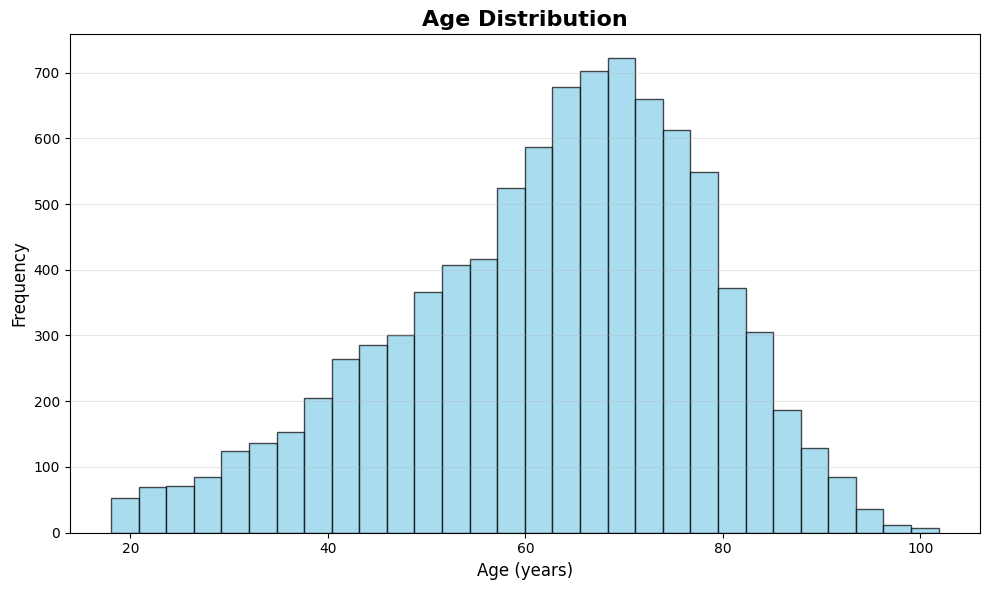

Age Statistics:
  Mean:   62.65 years
  Median: 64.86 years
  Std Dev:15.59 years
  Range:  18 - 102 years


In [246]:
# --- Age Distribution  ---

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Age Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

# Statistics 
print("Age Statistics:")
print(f"  Mean:   {df['age'].mean():.2f} years")
print(f"  Median: {df['age'].median():.2f} years")
print(f"  Std Dev:{df['age'].std():.2f} years")
print(f"  Range:  {df['age'].min():.0f} - {df['age'].max():.0f} years")

#### Age Distribution



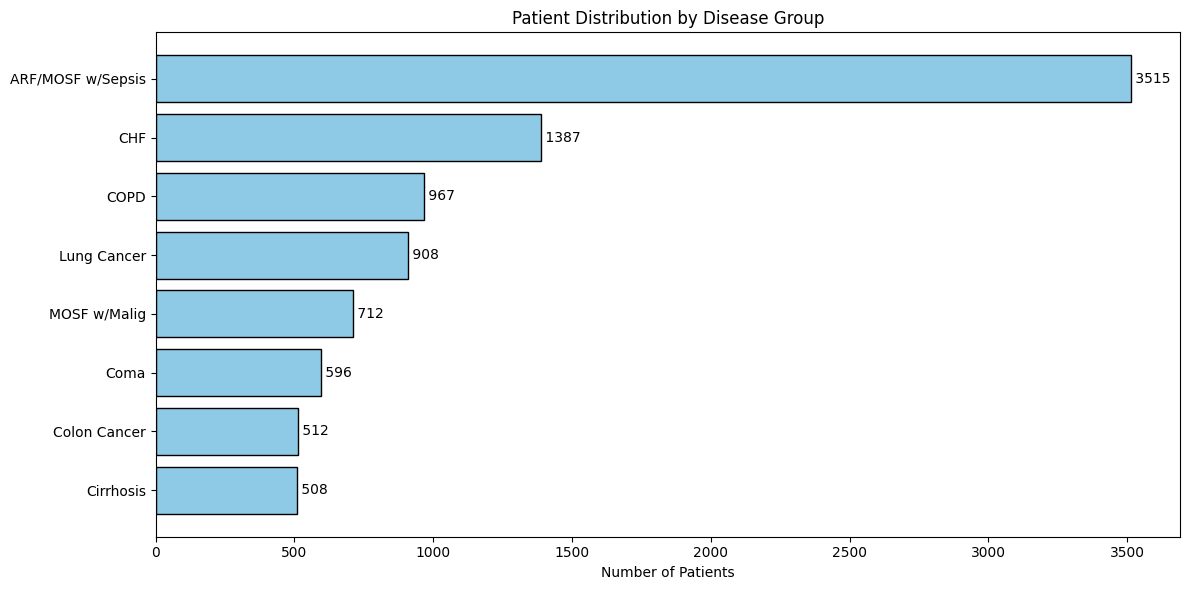

In [247]:
# --- Disease Category Distribution ---

if "dzgroup" in df.columns:
    counts = df["dzgroup"].value_counts()
    plt.figure(figsize=(12, 6))
    bars = plt.barh(counts.index, counts.values, color="#8ecae6", edgecolor="black")
    plt.xlabel("Number of Patients")
    plt.title("Patient Distribution by Disease Group")
    plt.gca().invert_yaxis()

    for b in bars:
        plt.text(
            b.get_width(),
            b.get_y() + b.get_height() / 2,
            f" {int(b.get_width())}",
            va="center"
        )

    plt.tight_layout()
    plt.show()
else:
    print("Column 'dzgroup' not found in the dataset.")

#### Disease Category Distribution


In [248]:
TARGET = 'hospdead'
y = df[TARGET]

print(f"Target variable: {TARGET}")
print(f"\nClass distribution:")
print(y.value_counts().sort_index())
print(f"\nClass distribution (percentage):")
print(y.value_counts(normalize=True).sort_index() * 100)


Target variable: hospdead

Class distribution:
hospdead
0    6745
1    2360
Name: count, dtype: int64

Class distribution (percentage):
hospdead
0    74.080176
1    25.919824
Name: proportion, dtype: float64


#### Target Variable Analysis (`hospdead`)



#### Target Distribution


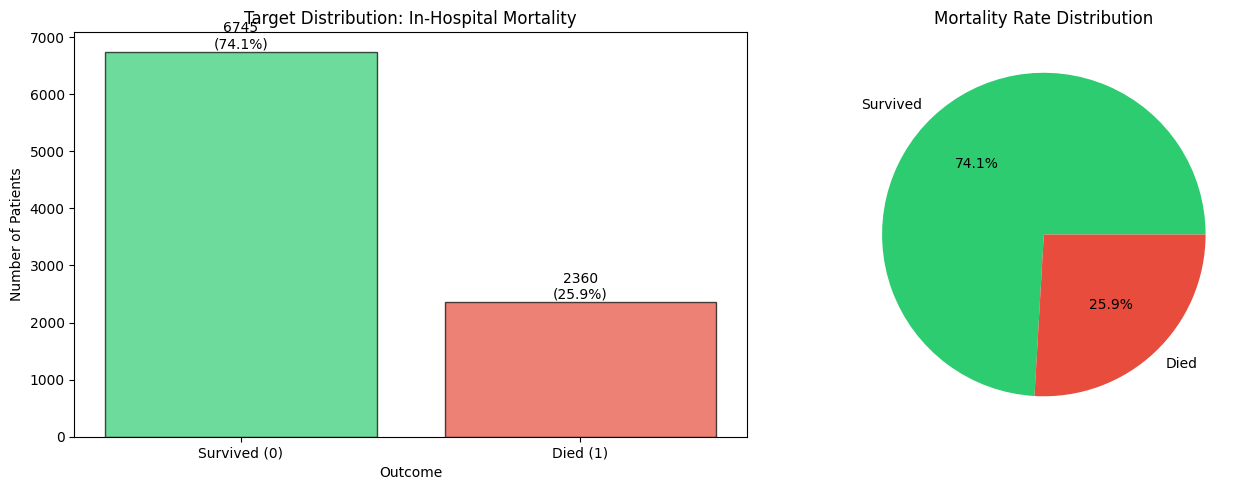

In [249]:
# --- Target Distribution  ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df["hospdead"].value_counts().sort_index()

bars = axes[0].bar(
    ["Survived (0)", "Died (1)"],
    counts.values,
    color=["#2ecc71", "#e74c3c"],
    edgecolor="black",
    alpha=0.7
)
axes[0].set_title("Target Distribution: In-Hospital Mortality")
axes[0].set_ylabel("Number of Patients")
axes[0].set_xlabel("Outcome")

for b in bars:
    h = b.get_height()
    axes[0].text(
        b.get_x() + b.get_width() / 2,
        h,
        f"{int(h)}\n({h/len(df)*100:.1f}%)",
        ha="center",
        va="bottom",
    )

axes[1].pie(
    counts.values,
    labels=["Survived", "Died"],
    colors=["#2ecc71", "#e74c3c"],
    autopct="%1.1f%%",
)
axes[1].set_title("Mortality Rate Distribution")

plt.tight_layout()
plt.show()

#### Correlation Analysis

Correlation matrices are generated to visualize relationships between features and the target variable, helping to identify strong predictors.



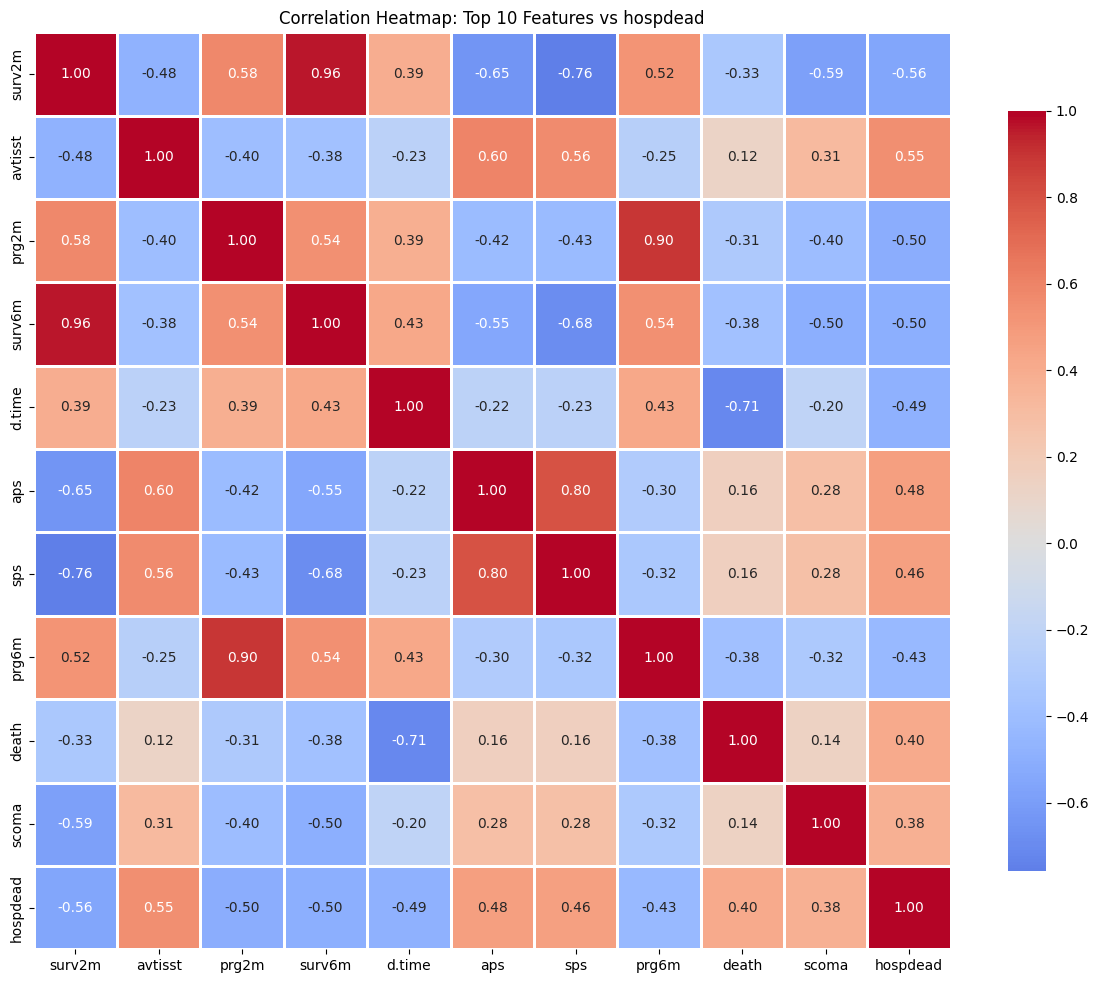


Top 10 Features Most Correlated with hospdead:
 1. surv2m              : 0.5581
 2. avtisst             : 0.5525
 3. prg2m               : 0.5040
 4. surv6m              : 0.4981
 5. d.time              : 0.4866
 6. aps                 : 0.4759
 7. sps                 : 0.4626
 8. prg6m               : 0.4302
 9. death               : 0.4048
10. scoma               : 0.3796


In [250]:
# --- Correlation Analysis  ---
numeric_df = df.select_dtypes(include=["int64", "float64"])  # numeric only
target_col = "hospdead"

if target_col in numeric_df.columns:
    corr_with_target = numeric_df.corr()[target_col].abs().sort_values(ascending=False)
    top_features = corr_with_target.drop(target_col).head(10).index.tolist()
    top_features.append(target_col)

    corr_matrix = numeric_df[top_features].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Correlation Heatmap: Top 10 Features vs hospdead")
    plt.tight_layout()
    plt.show()

    print("\nTop 10 Features Most Correlated with hospdead:")
    for i, (feat, corr) in enumerate(corr_with_target.drop(target_col).head(10).items(), 1):
        print(f"{i:2d}. {feat:<20s}: {corr:.4f}")
else:
    print(f"Column '{target_col}' not found in numeric columns.")

### 4.5 Missing Values Analysis





In [251]:
# --- Missingness Overview ---
total_features = df.shape[1]
features_with_missing = int(df.isna().any(axis=0).sum())
missing_feature_pct = features_with_missing / total_features * 100

print("Missingness Overview")
print("=" * 40)
print(f"Features with at least 1 missing value: {features_with_missing}/{total_features}")
print(f"Percentage of features with missing values: {missing_feature_pct:.2f}%")

Missingness Overview
Features with at least 1 missing value: 33/48
Percentage of features with missing values: 68.75%


In [252]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100)

missing_df = pd.DataFrame({
    "Feature": missing.index,
    "Missing_Count": missing.values,
    "Missing_%": missing_pct.values
}).sort_values("Missing_Count", ascending=False)

top_missing = missing_df[missing_df["Missing_Count"] > 0].head(15)
top_missing


,Feature,Missing_Count,Missing_%
44,adlp,5641,61.954970
43,urine,4862,53.399231
41,glucose,4500,49.423394
42,bun,4352,47.797913
15,totmcst,3475,38.165843
36,alb,3372,37.034596
11,income,2982,32.751236
45,adls,2867,31.488193
37,bili,2601,28.566722
35,pafi,2325,25.535420


#### Missing Values (NaN) Heatmap

The heatmap below visualizes missingness patterns across the most incomplete variables, clearly highlighting features with large gaps (e.g., albumin/alb, glucose, pH when present).


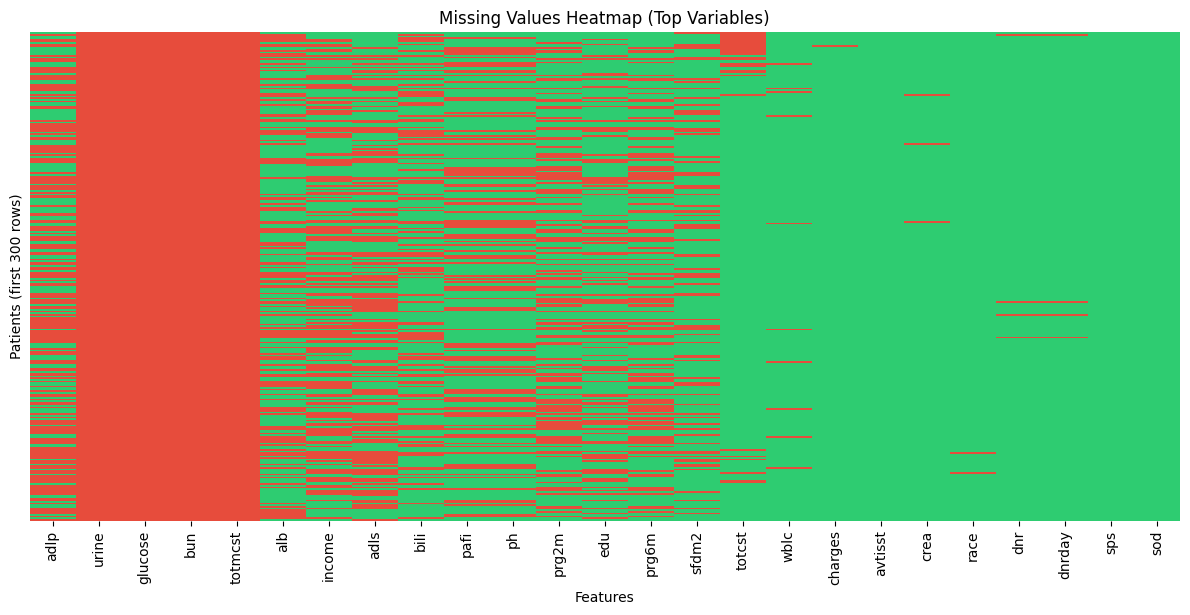

In [253]:
# --- Missing Values (NaN) Heatmap  ---

# Focus the heatmap on variables with the most missingness to keep it readable
missing_frac = df.isna().mean().sort_values(ascending=False)
missing_cols = missing_frac[missing_frac > 0].index.tolist()

if len(missing_cols) == 0:
    print("No missing values found in the dataset.")
else:
    # Take top columns with missingness + cap at 25 for readability
    top_missing_cols = missing_cols[:25]
    # Sample rows so the heatmap remains interpretable
    sample_n = min(300, len(df))
    sample_df = df[top_missing_cols].head(sample_n)

    plt.figure(figsize=(12, max(6, 0.25 * len(top_missing_cols))))
    sns.heatmap(
        sample_df.isna(),
        cmap=sns.color_palette(["#2ecc71", "#e74c3c"], as_cmap=True),  # green=present, red=missing
        cbar=False,
        yticklabels=False,
    )
    plt.title("Missing Values Heatmap (Top Variables)")
    plt.xlabel("Features")
    plt.ylabel(f"Patients (first {sample_n} rows)")
    plt.tight_layout()

    plt.show()

#### Important Features with Missing Values

The bar chart ranks the variables with the largest missingness. Features such as **albumin/alb**, **glucose**, and **pH** are highlighted when present in the dataset.

**Figure 31:** Important features with missing values (Top 15).

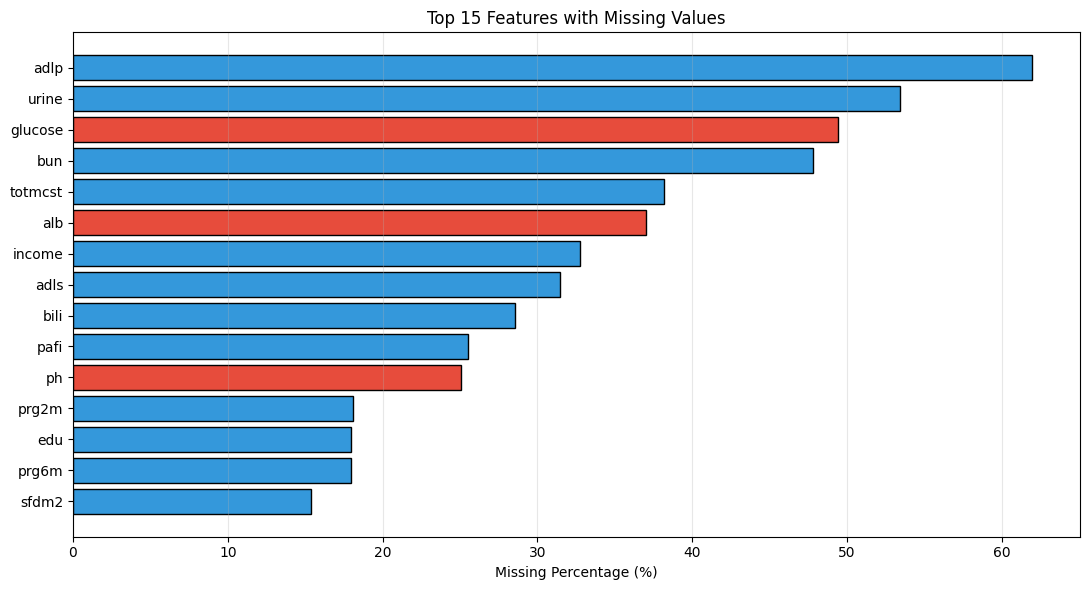

In [254]:
# --- Important Features with Missing Values (Figure 31) ---
import os

# Reuse top_missing from the previous cell (top 15 features with Missing_Count > 0)
if "top_missing" not in globals():
    top_missing = missing_df[missing_df["Missing_Count"] > 0].head(15)

if len(top_missing) > 0:
    # Highlight commonly missing clinical variables if present (case-insensitive match)
    highlight_features_lower = {"alb", "albumin", "glucose", "ph", "pao2", "paco2"}
    colors = [
        "#e74c3c" if str(f).lower() in highlight_features_lower else "#3498db"
        for f in top_missing["Feature"]
    ]

    plt.figure(figsize=(11, 6))
    plt.barh(top_missing["Feature"], top_missing["Missing_%"], color=colors, edgecolor="black")
    plt.xlabel("Missing Percentage (%)")
    plt.title("Top 15 Features with Missing Values")
    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    plt.show()
else:
    print("No features with missing values to plot.")

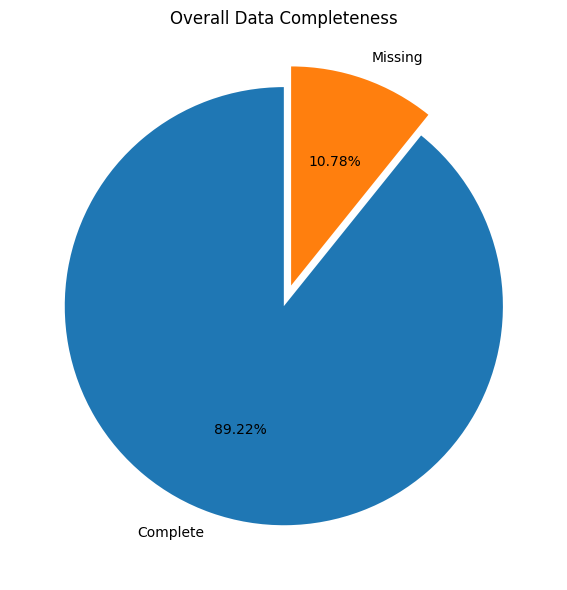

In [255]:
total_missing = missing.sum()
total_cells = df.shape[0] * df.shape[1]
total_complete = total_cells - total_missing

plt.figure(figsize=(6, 6))
plt.pie(
    [total_complete, total_missing],
    labels=["Complete", "Missing"],
    autopct="%1.2f%%",
    startangle=90,
    explode=(0, 0.1)
)
plt.title("Overall Data Completeness")
plt.tight_layout()
plt.show()


### Missing Values Visualization


### 4.6 Data Pre-processing

#### Feature Selection



In [256]:
# --- 4.6 Feature Selection (Leakage/IDs/Timestamps/High-missing) ---

target = TARGET if "TARGET" in globals() else "hospdead"

# Columns removed to prevent leakage / poor generalization.
leakage_cols = [
    "death",      # Alternate mortality outcome (not in-hospital); leaks future/out-of-scope outcome info
    "slos",       # Hospital length-of-stay; known only after admission/discharge (post-outcome)
    "d.time",     # Follow-up / time-to-event style field; outcome-dependent / future information
    "surv2m",     # Survival estimate at a future horizon; derived/engineered from outcome-related info
    "surv6m",     # Survival estimate at a future horizon; derived/engineered from outcome-related info
    "prg2m",      # Physician prognosis at a future horizon; may incorporate outcome knowledge/bias
    "prg6m",      # Physician prognosis at a future horizon; may incorporate outcome knowledge/bias
    "dnr",        # Do-not-resuscitate order indicator; can be downstream of deterioration/outcome
    "dnrday",     # Timing/day of DNR order; only known during/after the hospital course
    "sfdm2",      # Functional disability at 2 months; future measurement (not available at admission)
    "totcst",     # Total cost of care; administrative/post-hoc field, not available at prediction time
    "charges",    # Billing/charges; administrative/post-hoc field, not available at prediction time
    "totmcst",    # Total medical cost (if present); administrative/post-hoc field
    "totccst",    # Total charges/cost (if present); administrative/post-hoc field
    "hospdt",     # Hospital discharge datetime/date (if present); not available at admission
    "admdt",      # Admission datetime/date (if present); raw timestamp (useful only if engineered)
    "dischdt",    # Discharge datetime/date (if present); not available at admission
    "disdt",      # Discharge date/time variant (if present); not available at admission
    "deathdt",    # Date/time of death (if present); direct leakage of the outcome
    "dthdt",      # Date/time of death variant (if present); direct leakage of the outcome
    "hospid",     # Hospital/site identifier (if present); administrative, may add bias / poor transferability
    "site",       # Hospital/site code (if present); administrative, may add bias / poor transferability
    "hospital",   # Hospital identifier (if present); administrative, may add bias / poor transferability
    "adm_source", # Admission source (if present); administrative/contextual, may not generalize
    "admtype",    # Admission type (if present); administrative/contextual, may not generalize
    "source",     # Generic source field (if present); administrative/contextual, may not generalize
    "zipcode",    # Patient ZIP/postcode (if present); location/PII, can introduce bias/leakage
    "zip",        # ZIP/postcode variant (if present); location/PII, can introduce bias/leakage
    "phone",      # Patient phone (if present); PII/identifier, no clinical predictive value
    "name",       # Patient name (if present); PII/identifier, no clinical predictive value
    "address",    # Patient address (if present); PII/identifier, no clinical predictive value
    "ssn",        # Social security number (if present); PII/identifier, no clinical predictive value
    "mrn",        # Medical record number (if present); identifier, can cause memorization
 ]

# 2) Patient ID-like columns (heuristic: contains 'id' AND almost all values unique)
id_like = []
for c in df.columns:
    cl = str(c).lower()
    if c == target:
        continue
    if "id" in cl:
        try:
            nunique = df[c].nunique(dropna=True)
            if nunique >= 0.98 * len(df):
                id_like.append(c)
        except Exception:
            pass

# 3) Timestamp-like columns (name-based + datetime dtype)
time_like = []
for c in df.columns:
    if c == target:
        continue
    cl = str(c).lower()
    if any(tok in cl for tok in ["date", "time", "timestamp", "datetime"]):
        time_like.append(c)
    if np.issubdtype(df[c].dtype, np.datetime64):
        time_like.append(c)

# 4) Columns with >70% missing values
missing_rate = df.isna().mean()
high_missing = missing_rate[missing_rate > 0.70].index.tolist()
high_missing = [c for c in high_missing if c != target]

drop_cols = sorted(set([c for c in leakage_cols if c in df.columns] + id_like + time_like + high_missing) - {target})
df_clean = df.drop(columns=drop_cols, errors="ignore")

print("Feature Selection Summary")
print("=" * 40)
print(f"Target: {target}")
print(f"Dropped columns: {len(drop_cols)}")
if len(drop_cols) > 0:
    print("Dropped:", drop_cols)
print(f"Remaining columns (incl. target): {df_clean.shape[1]}")

y = df_clean[target]
X = df_clean.drop(columns=[target])

print(f"Features (X): {X.shape[1]} columns")
print(f"Target (y): {y.shape[0]} rows")

Feature Selection Summary
Target: hospdead
Dropped columns: 14
Dropped: ['ID', 'charges', 'd.time', 'death', 'dnr', 'dnrday', 'prg2m', 'prg6m', 'sfdm2', 'slos', 'surv2m', 'surv6m', 'totcst', 'totmcst']
Remaining columns (incl. target): 34
Features (X): 33 columns
Target (y): 9105 rows


### Train-Test Split



In [257]:
from sklearn.model_selection import train_test_split

# Split raw features (no imputation/encoding/scaling yet)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
 )

In [258]:
# ---  Train/test split sizes + class balance ---
print("Train/Test Split Summary")
print("=" * 40)
print(f"Total rows:  {len(X):,}")
print(f"Train rows:  {len(X_train_raw):,} ({len(X_train_raw)/len(X)*100:.1f}%)")
print(f"Test rows:   {len(X_test_raw):,} ({len(X_test_raw)/len(X)*100:.1f}%)")

print("\nClass distribution in training set (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nClass distribution in test set (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train/Test Split Summary
Total rows:  9,105
Train rows:  7,284 (80.0%)
Test rows:   1,821 (20.0%)

Class distribution in training set (%):
hospdead
0    74.08
1    25.92
Name: proportion, dtype: float64

Class distribution in test set (%):
hospdead
0    74.08
1    25.92
Name: proportion, dtype: float64


### Handling Missing Values (Imputation)


In [259]:
# --- Handling Missing Values (Imputation; leakage-safe) ---

# Identify column types from training set only
num_cols = X_train_raw.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns

print("Preprocessing: Missing Value Handling")
print("=" * 40)
print(f"Train shape (raw): {X_train_raw.shape}")
print(f"Test shape  (raw): {X_test_raw.shape}")
print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

# Compute imputation values on TRAIN only
train_num_medians = X_train_raw[num_cols].median() if len(num_cols) else pd.Series(dtype=float)
train_cat_modes = (X_train_raw[cat_cols].mode().iloc[0] if len(cat_cols) else pd.Series(dtype=object))

# Apply imputation to both train and test
X_train_imputed = X_train_raw.copy()
X_test_imputed = X_test_raw.copy()

if len(num_cols) > 0:
    X_train_imputed[num_cols] = X_train_imputed[num_cols].fillna(train_num_medians)
    X_test_imputed[num_cols] = X_test_imputed[num_cols].fillna(train_num_medians)

if len(cat_cols) > 0:
    X_train_imputed[cat_cols] = X_train_imputed[cat_cols].fillna(train_cat_modes)
    X_test_imputed[cat_cols] = X_test_imputed[cat_cols].fillna(train_cat_modes)

print(f"Missing (train, after impute): {int(X_train_imputed.isna().sum().sum())}")
print(f"Missing (test, after impute):  {int(X_test_imputed.isna().sum().sum())}")

Preprocessing: Missing Value Handling
Train shape (raw): (7284, 33)
Test shape  (raw): (1821, 33)
Numeric features: 27
Categorical features: 6
Missing (train, after impute): 0
Missing (test, after impute):  0


### Encode Categorical Variables

After imputation, categorical variables are converted into numeric features using **one-hot encoding**. To prevent train/test mismatch, we **align the encoded columns** so both sets have identical features (missing categories in the test set become 0).

In [260]:
# --- One-hot encode categorical features (train/test aligned) ---
# Fit encoding on TRAIN categories and align TEST columns to TRAIN
X_train_encoded = pd.get_dummies(X_train_imputed, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_imputed, drop_first=True)

# Align columns so train/test have identical feature space
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Keep the variable names used downstream in the notebook
X_train = X_train_encoded
X_test = X_test_encoded
X_encoded = pd.concat([X_train, X_test], axis=0)  # for reference/shape checks only
print(f"Encoded train shape: {X_train.shape}")
print(f"Encoded test shape:  {X_test.shape}")

Encoded train shape: (7284, 47)
Encoded test shape:  (1821, 47)


### Feature Scaling



In [261]:
# Scale features (fit on TRAIN only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled test shape:  {X_test_scaled.shape}")

Scaled train shape: (7284, 47)
Scaled test shape:  (1821, 47)


### 4.7 Model Training and Evaluation

#### 4.7.1 Logistic Regression



In [262]:
# Initialize model
lr = LogisticRegression(max_iter=2000, random_state=42)

# Train model
lr.fit(X_train_scaled, y_train)

print("✓ Logistic Regression model trained successfully")

y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]



✓ Logistic Regression model trained successfully


### Performance Metrics


In [263]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")


LOGISTIC REGRESSION - PERFORMANCE METRICS
Accuracy:  0.8539 (85.39%)
Precision: 0.7641
Recall:    0.6314
F1-Score:  0.6914
ROC-AUC:   0.9124


### Confusion Matrix
Show how many predictions fall into each category (true/false positives/negatives)


Confusion Matrix:
                Predicted
              Survived  Died
Actual Survived   1257     92
       Died        174    298


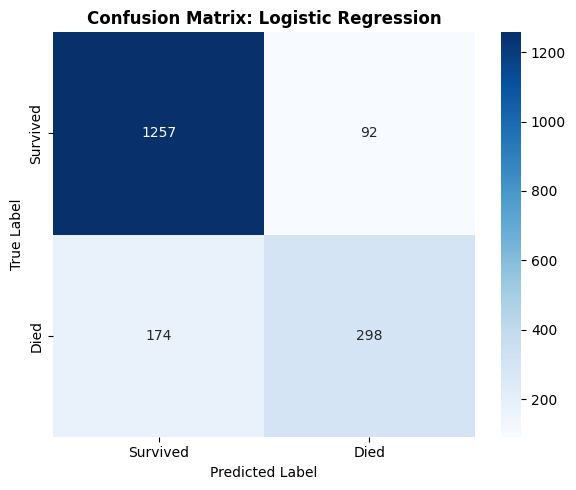

In [264]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Survived  Died")
print(f"Actual Survived  {cm[0][0]:5d}  {cm[0][1]:5d}")
print(f"       Died      {cm[1][0]:5d}  {cm[1][1]:5d}")

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix: Logistic Regression', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


### Classification Report
### ROC Curve
Plot the ROC curve to visualize the tradeoff between True Positive Rate (recall) and False Positive Rate across thresholds.

              precision    recall  f1-score   support

    Survived       0.88      0.93      0.90      1349
        Died       0.76      0.63      0.69       472

    accuracy                           0.85      1821
   macro avg       0.82      0.78      0.80      1821
weighted avg       0.85      0.85      0.85      1821



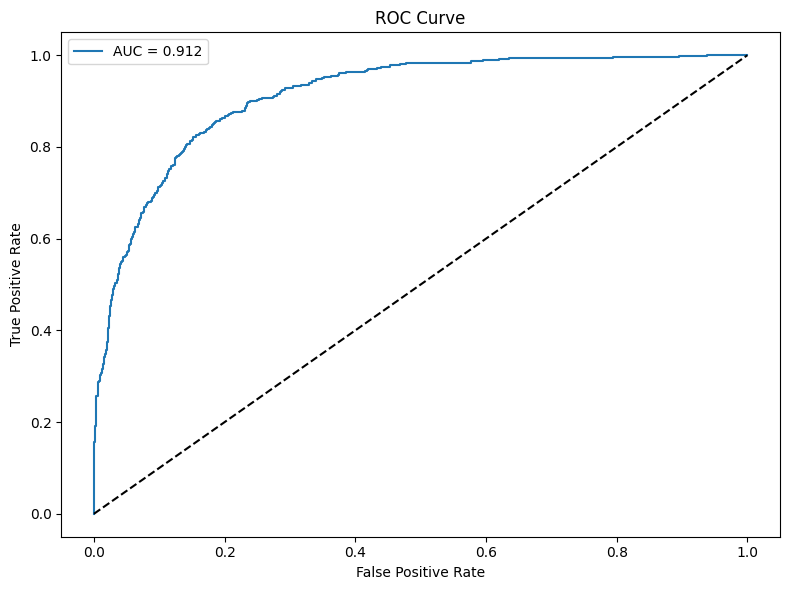

In [265]:
# text metrics
print(classification_report(y_test, y_pred, target_names=["Survived", "Died"]))  
# ROC points 
fpr, tpr, _ = roc_curve(y_test, y_proba)  
 # AUC value
auc = roc_auc_score(y_test, y_proba)     

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [266]:
# Summary Statisitics
summary = pd.DataFrame({
    'Metric': [
        'Total Patients',
        'Total Features',
        'Numeric Features',
        'Categorical Features',
        'Survived Count',
        'Died Count',
        'Survival Rate (%)'
    ],
    'Value': [
        df.shape[0],
        df.shape[1],
        len(num_cols),
        len(cat_cols),
        (df['hospdead'] == 0).sum(),
        (df['hospdead'] == 1).sum(),
        round((df['hospdead'] == 0).sum() / len(df) * 100, 2)
    ]
})



#### 4.7.2 K-Nearest Neighbours (KNN)



K-Nearest Neighbors Model trained successfully with k=5.
KNN model predictions generated.

--- KNN Model Evaluation ---
--- KNN Summary Metrics ---
knn_accuracy : 0.8232
knn_precision: 0.7517
knn_recall   : 0.4746
knn_f1       : 0.5818
knn_auc      : 0.8226

Confusion Matrix:
|                     |   Predicted Survived (0) |   Predicted Died (1) |
|:--------------------|-------------------------:|---------------------:|
| Actual Survived (0) |                     1275 |                   74 |
| Actual Died (1)     |                      248 |                  224 |


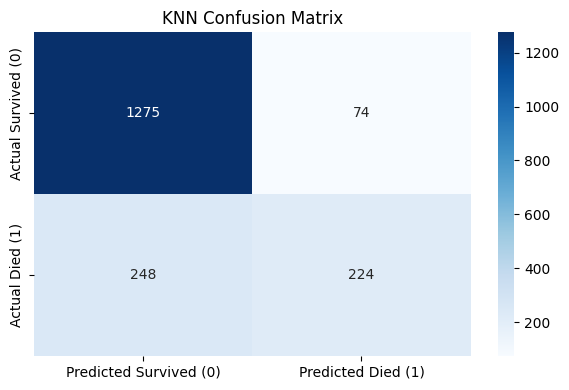


Classification Report:
              precision    recall  f1-score   support

Survived (0)       0.84      0.95      0.89      1349
    Died (1)       0.75      0.47      0.58       472

    accuracy                           0.82      1821
   macro avg       0.79      0.71      0.73      1821
weighted avg       0.82      0.82      0.81      1821



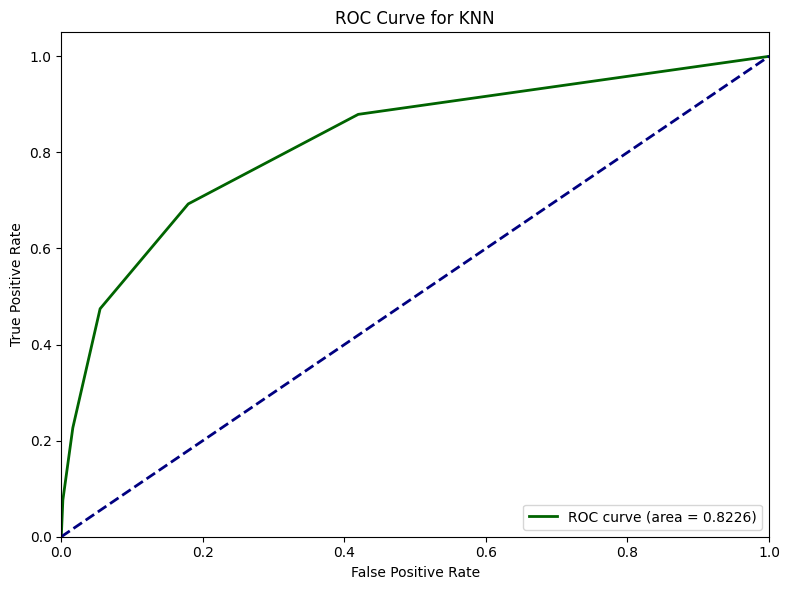

,KNN
accuracy,0.823174
precision,0.751678
recall,0.474576
f1,0.581818
auc,0.822591


In [267]:
# --- 4.7.2 Train + Evaluate: KNN ---

# --- Train the model (KNN) ---
# KNN should use scaled features (distance-based model)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
print("K-Nearest Neighbors Model trained successfully with k=5.")

# --- Test the model ---
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
print("KNN model predictions generated.")

# --- Evaluate the model ---
print("\n--- KNN Model Evaluation ---")

# Summary metrics required by documentation
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn, zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, zero_division=0)
knn_auc = roc_auc_score(y_test, y_pred_proba_knn)

print("--- KNN Summary Metrics ---")
print(f"knn_accuracy : {knn_accuracy:.4f}")
print(f"knn_precision: {knn_precision:.4f}")
print(f"knn_recall   : {knn_recall:.4f}")
print(f"knn_f1       : {knn_f1:.4f}")
print(f"knn_auc      : {knn_auc:.4f}")

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_df = pd.DataFrame(
    cm_knn,
    index=["Actual Survived (0)", "Actual Died (1)"],
    columns=["Predicted Survived (0)", "Predicted Died (1)"],
)
print("\nConfusion Matrix:")
print(cm_df.to_markdown())

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=["Survived (0)", "Died (1)"]))

# ROC Curve (save to workspace + show inline)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkgreen', lw=2, label=f'ROC curve (area = {knn_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve for KNN")
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

# Optional: neat display table
metrics_knn = {
    "accuracy": knn_accuracy,
    "precision": knn_precision,
    "recall": knn_recall,
    "f1": knn_f1,
    "auc": knn_auc,
}
display(pd.DataFrame([metrics_knn]).T.rename(columns={0: "KNN"}))


### 4.7.3 Decision Tree Classifier


In [268]:
# -- Decision Tree --

# Constrained tree to reduce overfitting and keep paths clinically interpretable
dt = DecisionTreeClassifier(
    max_depth=5,
    criterion="gini",
    min_samples_leaf=20,
    random_state=42,
)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_proba_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)
print(f"Decision Tree Accuracy: {dt_acc:.4f} | AUC: {dt_auc:.4f} | Recall: {dt_rec:.4f} | F1: {dt_f1:.4f}")


Decision Tree Accuracy: 0.8446 | AUC: 0.8815 | Recall: 0.6822 | F1: 0.6947


In [269]:
# --- 4.7.4 Train: Random Forest (on scaled features) ---
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Predictions (keep for downstream comparison)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Quick summary (full evaluation in the next cells)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_proba_rf)
rf_rec = recall_score(y_test, y_pred_rf, zero_division=0)



In [270]:
# --- Random Forest: full metrics ---
rf_prec = precision_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

print("RANDOM FOREST - PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall:    {rf_rec:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

RANDOM FOREST - PERFORMANCE METRICS
Accuracy:  0.8578 (85.78%)
Precision: 0.7934
Recall:    0.6102
F1-Score:  0.6898
ROC-AUC:   0.9086


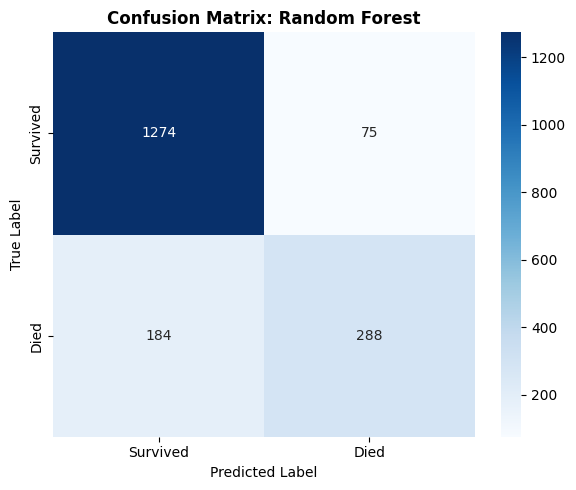

In [271]:
# --- Random Forest: confusion matrix ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Survived', 'Died'],
    yticklabels=['Survived', 'Died']
)
plt.title('Confusion Matrix: Random Forest', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [272]:
# --- Random Forest: classification report ---
print(classification_report(y_test, y_pred_rf, target_names=["Survived", "Died"]))

              precision    recall  f1-score   support

    Survived       0.87      0.94      0.91      1349
        Died       0.79      0.61      0.69       472

    accuracy                           0.86      1821
   macro avg       0.83      0.78      0.80      1821
weighted avg       0.85      0.86      0.85      1821



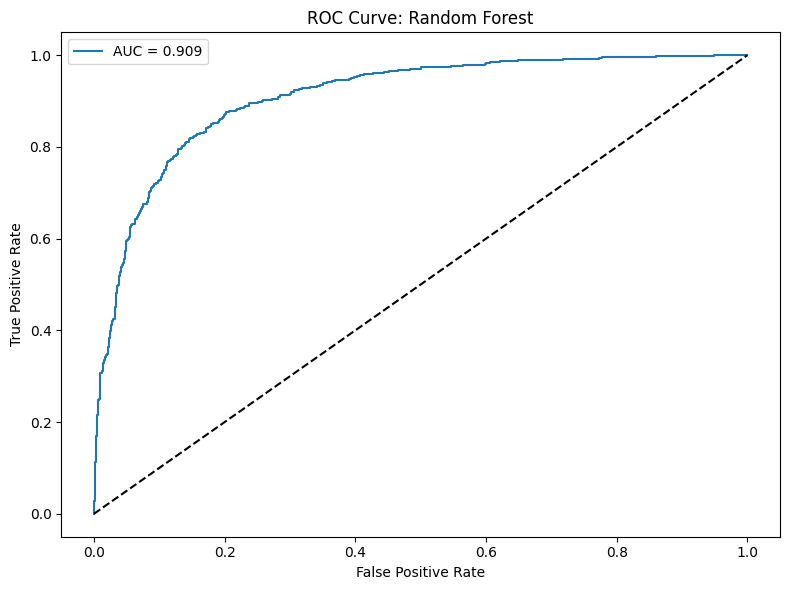

In [273]:
# --- Random Forest: ROC curve ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {rf_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

### 4.8 Model Comparison


In [274]:
# Comparison Table 
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc, knn_accuracy, dt_acc, rf_acc],
    'Precision': [prec, knn_precision, precision_score(y_test, y_pred_dt, zero_division=0), 
                  precision_score(y_test, y_pred_rf, zero_division=0)],
    'Recall': [rec, knn_recall, dt_rec, rf_rec],
    'F1': [f1, knn_f1, dt_f1, rf_f1],
    'AUC': [auc, knn_auc, dt_auc, rf_auc],
})
models_comparison = models_comparison.round(4)
models_comparison


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8539,0.7641,0.6314,0.6914,0.9124
1,KNN,0.8232,0.7517,0.4746,0.5818,0.8226
2,Decision Tree,0.8446,0.7077,0.6822,0.6947,0.8815
3,Random Forest,0.8578,0.7934,0.6102,0.6898,0.9086


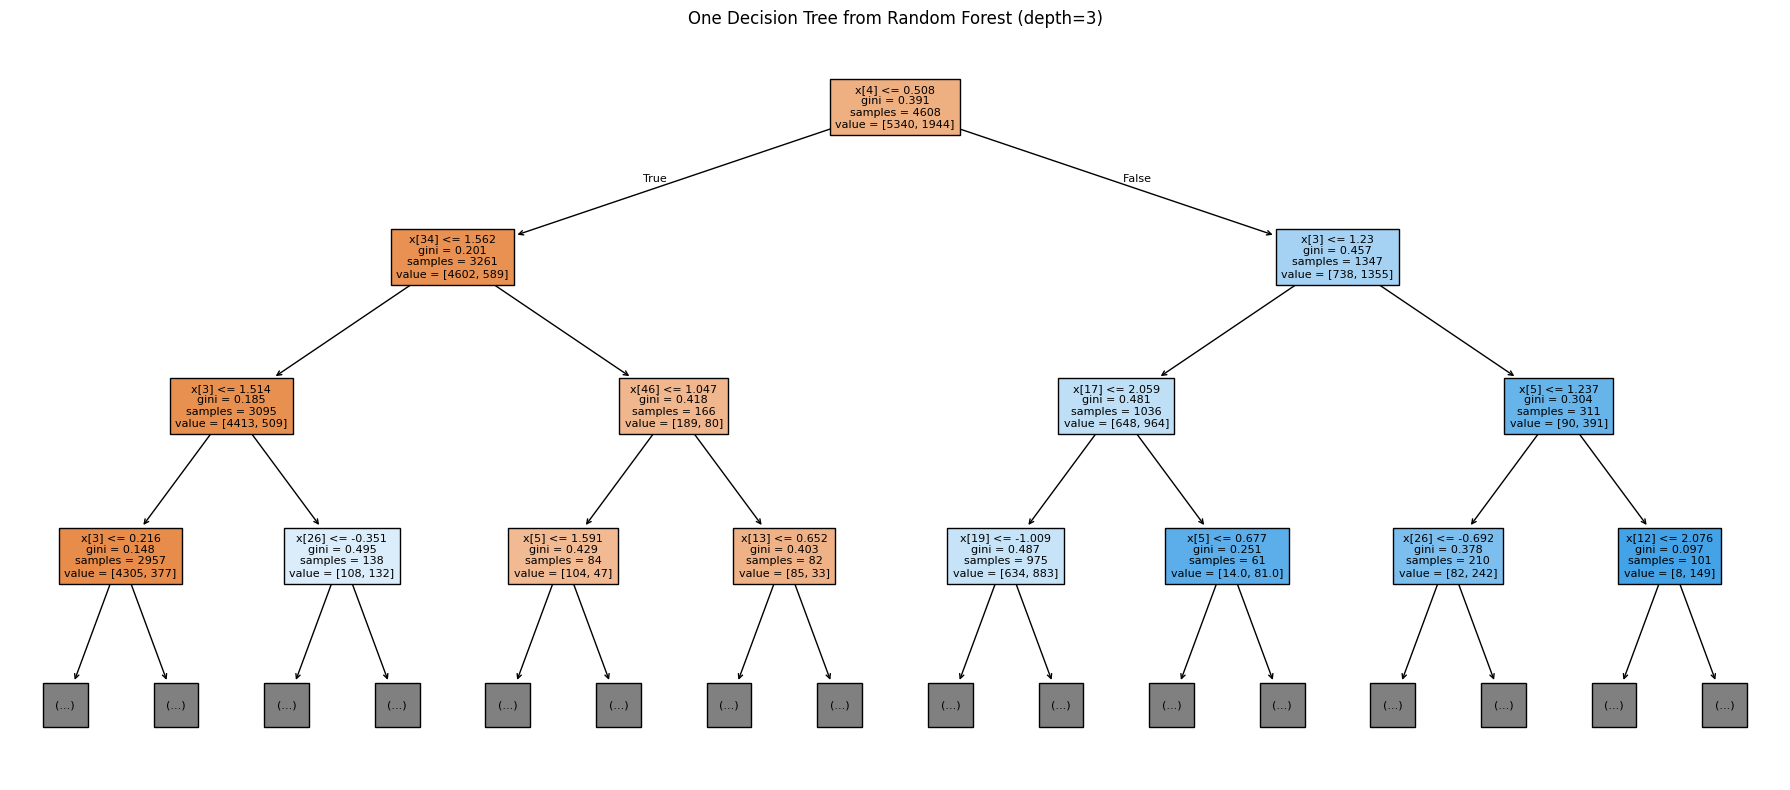

In [275]:

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree0 = rf.estimators_[0]  # take 1 tree from the forest 

plt.figure(figsize=(18, 8))
plot_tree(tree0, max_depth=3, filled=True, fontsize=8)  # limit depth so it's readable 
plt.title("One Decision Tree from Random Forest (depth=3)")
plt.tight_layout()
plt.show()



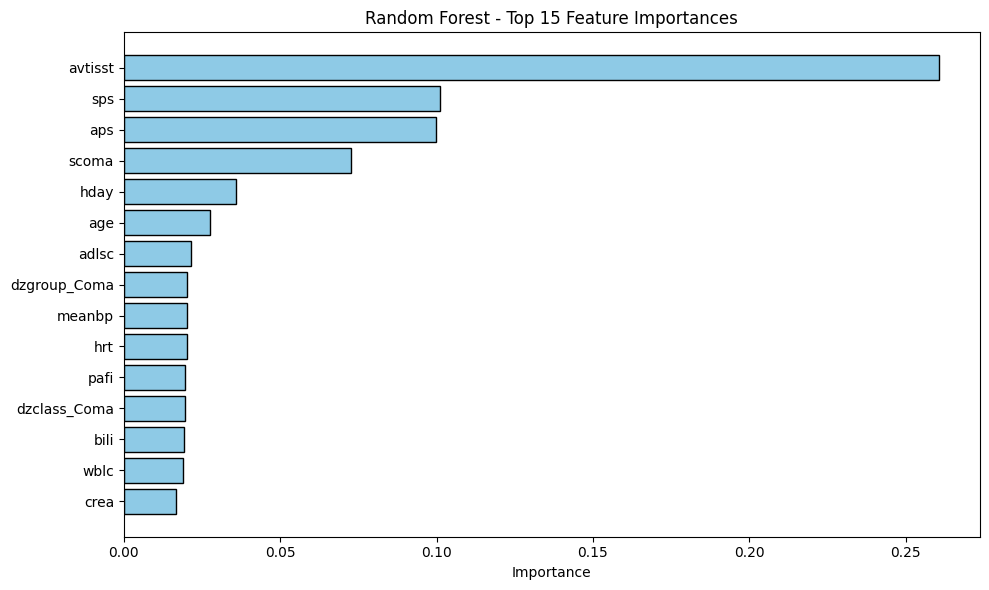

,importance
avtisst,0.260759
sps,0.101156
aps,0.099975
scoma,0.072620
hday,0.035725
age,0.027523
adlsc,0.021397
dzgroup_Coma,0.020163
meanbp,0.020152
hrt,0.020064


In [276]:
# --- Random Forest: Top 15 Feature Importances ---
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top15 = imp.head(15).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top15.index, top15.values, color="#8ecae6", edgecolor="black")
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(imp.head(15).to_frame("importance"))

Top 20 Most Important Features:
                       feature  importance
4                      avtisst    0.260759
5                          sps    0.101156
6                          aps    0.099975
3                        scoma    0.072620
7                         hday    0.035725
0                          age    0.027523
26                       adlsc    0.021397
32                dzgroup_Coma    0.020163
10                      meanbp    0.020152
12                         hrt    0.020064
15                        pafi    0.019614
37                dzclass_Coma    0.019454
17                        bili    0.019154
11                        wblc    0.018899
18                        crea    0.016598
14                        temp    0.015346
19                         sod    0.014874
35  dzclass_COPD/CHF/Cirrhosis    0.014525
13                        resp    0.014090
20                          ph    0.013786


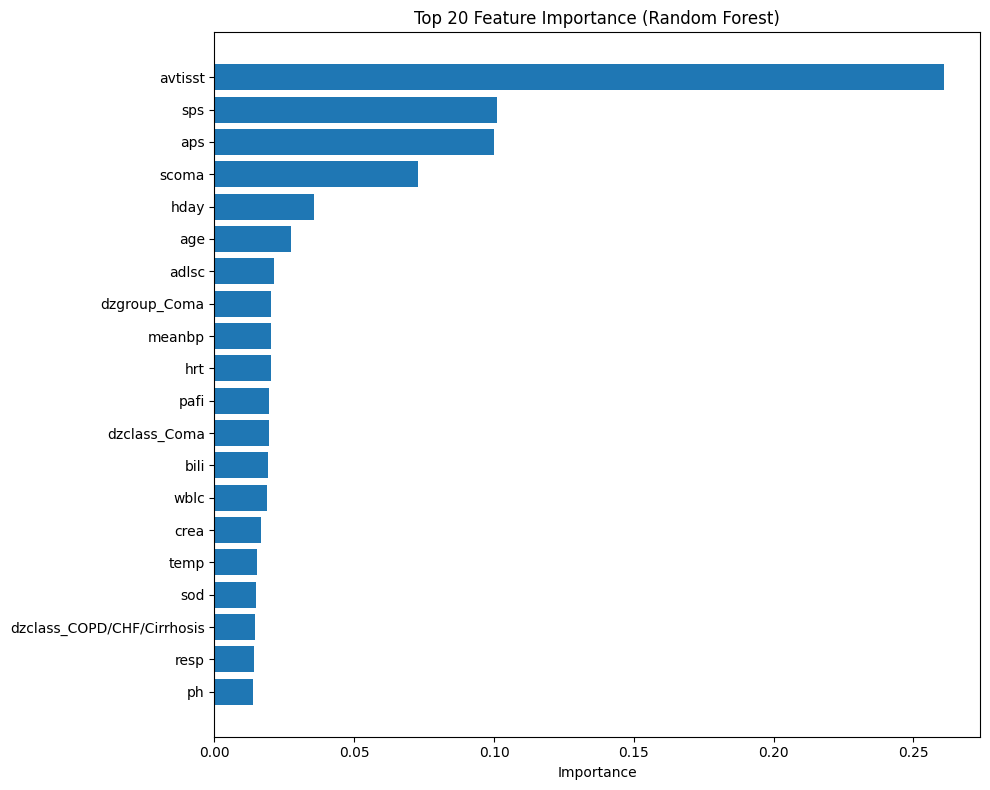

In [277]:
# After training  Random Forest model
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 20 features
print("Top 20 Most Important Features:")
print(feature_importance.head(20))

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(20)['feature'], feature_importance.head(20)['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


In [283]:

# =====  Feature Selection (Keep Most Important) =====
# Select clinically relevant features with good data quality
FEATURES_TO_USE = [
    # Severity scores (usually most important)
    'sps',           # SUPPORT physiological score
    'aps',           # APACHE physiological score
    
    # Demographics
    'age',           # Age in years
    
    # Physiological measurements
    'meanbp',        # Mean arterial blood pressure
    'hrt',           # Heart rate
    'resp',          # Respiratory rate
    'temp',          # Temperature
    
    # Laboratory values
    'crea',          # Serum creatinine (kidney function)
    'sod',        # Serum sodium
    'ph',            # Blood pH
    'pafi',          # PaO2/FiO2 ratio (oxygenation)
    'alb',           # Albumin
    'bili',          # Bilirubin (liver function)
    'wblc',          # White blood cell count
    'glucose',       # Blood glucose
    
    # Clinical indicators
    'scoma',         # Coma score
    'adlsc',         # Activities of Daily Living score
    'hday',          # Hospital day
    
    # Categorical features
    'dzgroup',       # Disease group
    'sex',           # Gender
]

TARGET = 'hospdead'

# ===== 3. Handle Missing Values =====
# Create a copy with selected features
df_model = df[FEATURES_TO_USE + [TARGET]].copy()

# For numerical features: fill with median
numerical_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove(TARGET)  # Don't fill target

for col in numerical_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())


# For categorical features: fill with mode
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])


print(f"After feature selection: {df_model.shape}")
print(f"Missing values remaining: {df_model.isnull().sum().sum()}")

# ===== 4. Prepare Features and Target =====
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=False)  
print(f"After encoding: {X_encoded.shape[1]} features")

# Store feature names for later use
feature_names = X_encoded.columns.tolist()

# ===== 5. Train-Test Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# ===== 6. Scale Features =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== 7. Train Random Forest =====
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# ===== 8. Evaluate Model =====
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]


# ===== 9. Feature Importance =====
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)


print("\nTop 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

# ===== 10. Save Model Artifacts =====
model_artifact = {
    'model': rf,
    'scaler': scaler,
    'feature_names': feature_names,
    'feature_importance': feature_importance_df,
    'categorical_features': categorical_cols,
    'numerical_features': numerical_cols,
    'performance': {
        'accuracy': rf_acc,
        'auc': rf_auc,
        'recall': rf_rec
    }
}

with open("model.pkl", "wb") as f:
    pickle.dump(model_artifact, f, protocol=5)

print("\n Model saved to 'model.pkl'")
print(f"   Total features: {len(feature_names)}")


After feature selection: (9105, 21)
Missing values remaining: 0
After encoding: 28 features

Training Random Forest...

Top 15 Most Important Features:
             feature  importance
                 sps    0.203091
                 aps    0.196774
               scoma    0.140891
                hday    0.070881
        dzgroup_Coma    0.045519
               adlsc    0.035190
                 age    0.029089
              meanbp    0.026063
                pafi    0.023674
                 hrt    0.022984
                wblc    0.022415
                crea    0.021255
dzgroup_MOSF w/Malig    0.020471
                bili    0.019722
                 sod    0.016821

 Model saved to 'model.pkl'
   Total features: 28
